# Post-Hoc FDP Bounds

Think of the p-value threshold as a review knob: moving it up selects more possible anomalies, but also risks more false alarms. FDP bounds turn that knob into a certified curve, so you can inspect the tradeoff and then choose a threshold after seeing it.

The plot below is the analogue of a ROC or precision-recall curve for this method: it shows how many discoveries you get and what minimum precision is certified. Oddball labels are used only to evaluate the example, not to fit the detector or compute the certificate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from oddball import Dataset, load
from pyod.models.iforest import IForest
from scipy.stats import false_discovery_control

from nonconform import ConformalDetector, Split
from nonconform.fdr import conformal_fdp_upper_bound_from_result
from nonconform.metrics import false_discovery_rate, statistical_power

x_train, x_test, y_test = load(Dataset.SHUTTLE, setup=True, seed=42)

In [2]:
detector = ConformalDetector(
    detector=IForest(n_estimators=100, max_samples=0.8, random_state=42),
    strategy=Split(n_calib=1_000),
    seed=42,
)
detector.fit(x_train)
p_values = detector.compute_p_values(x_test)
bounds = conformal_fdp_upper_bound_from_result(detector.last_result, seed=42)

Test samples: 1000 (100 labeled anomalies)
Read fdp_bound as: among the selected discoveries, no more than this fraction is certified to be false at the requested confidence level.
precision_floor = 1 - fdp_bound; certified_min_hits is its count version.
Empirical columns use labels only to check the example afterward.

FDP-bound curve snapshots
 target_discoveries p_threshold  discoveries fdp_bound precision_floor  certified_min_hits empirical_fdp power
                 50       0.001           96     0.243           0.757                  73         0.000 0.960
                100       0.005          103     0.226           0.774                  80         0.049 0.980
                120       0.018          120     0.259           0.741                  89         0.183 0.980
                150       0.046          150     0.407           0.593                  89         0.333 1.000
                200       0.087          203     0.562           0.438                  89       

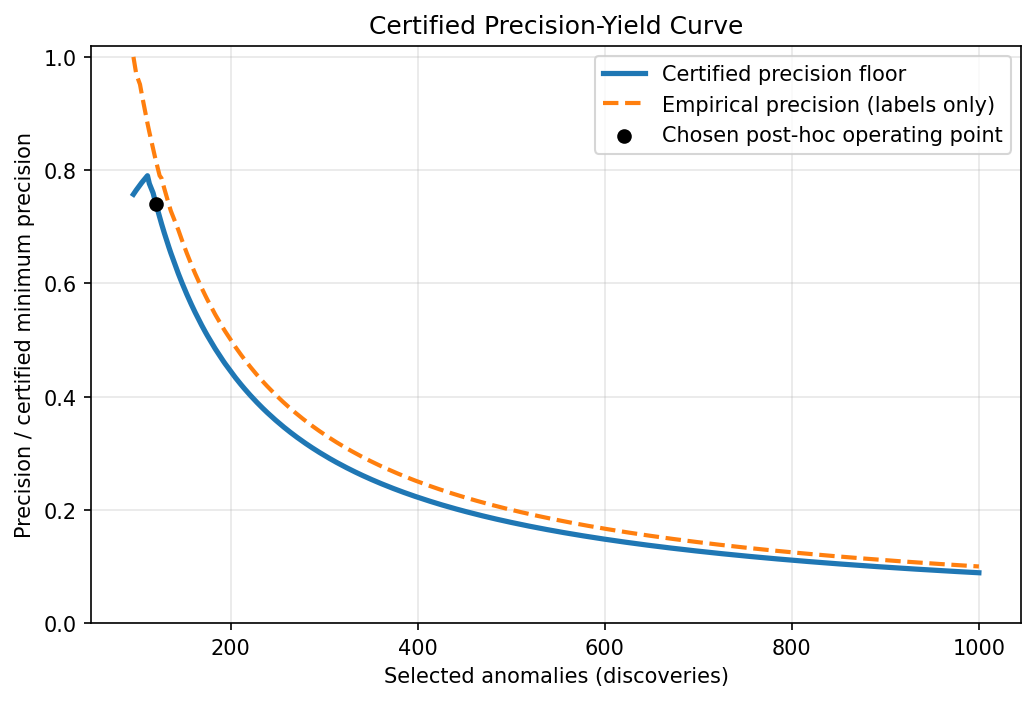

In [3]:
target_counts = [50, 100, 120, 150, 200]
curve_rows = []

frontier_rows = []
for threshold, discoveries, fdp_bound, precision_floor in zip(
    bounds.thresholds,
    bounds.rejection_counts,
    bounds.fdp_upper_bounds,
    bounds.precision_lower_bounds,
    strict=True,
):
    if discoveries == 0:
        continue
    selected = bounds.select(float(threshold))
    frontier_rows.append(
        {
            "p_threshold": float(threshold),
            "discoveries": int(discoveries),
            "fdp_bound": float(fdp_bound),
            "precision_floor": float(precision_floor),
            "empirical_precision": 1.0 - false_discovery_rate(y_test, selected),
            "empirical_fdp": false_discovery_rate(y_test, selected),
            "power": statistical_power(y_test, selected),
        }
    )
frontier = pd.DataFrame(frontier_rows)
frontier = frontier.loc[frontier.groupby("discoveries")["fdp_bound"].idxmin()]
frontier = frontier.sort_values("discoveries")

for target_count in target_counts:
    candidates = np.flatnonzero(frontier["discoveries"].to_numpy() >= target_count)
    if candidates.size == 0:
        continue
    row = frontier.iloc[int(candidates[0])]
    curve_rows.append(
        {
            "target_discoveries": target_count,
            "p_threshold": row.p_threshold,
            "discoveries": int(row.discoveries),
            "fdp_bound": row.fdp_bound,
            "precision_floor": row.precision_floor,
            "certified_min_hits": int(np.ceil(row.discoveries * row.precision_floor)),
            "empirical_fdp": row.empirical_fdp,
            "power": row.power,
        }
    )


def evaluated_selection(rule, selected, threshold, nominal_q="-"):
    """Return one evaluated row for an operating point."""
    discoveries = int(np.sum(selected))
    fdp_bound = bounds.bound_at(float(threshold))
    precision_floor = bounds.precision_at(float(threshold))
    return {
        "rule": rule,
        "q": nominal_q,
        "p_threshold": float(threshold),
        "discoveries": discoveries,
        "fdp_bound": fdp_bound,
        "precision_floor": precision_floor,
        "certified_min_hits": int(np.ceil(discoveries * precision_floor)),
        "empirical_fdp": false_discovery_rate(y_test, selected),
        "power": statistical_power(y_test, selected),
    }


min_discoveries = 120
chosen_idx = int(np.flatnonzero(bounds.rejection_counts >= min_discoveries)[0])
chosen_threshold = float(bounds.thresholds[chosen_idx])
chosen_selected = bounds.select(chosen_threshold)
chosen_row = evaluated_selection(
    f"FDP-bound choice: >= {min_discoveries} discoveries",
    chosen_selected,
    chosen_threshold,
)

bh_adjusted = false_discovery_control(p_values, method="bh")
bh_fixed_q = 0.10
bh_fixed_selected = bh_adjusted <= bh_fixed_q
bh_fixed_threshold = float(np.max(p_values[bh_fixed_selected]))

bh_relaxed_q = np.nan
bh_relaxed_selected = np.zeros_like(p_values, dtype=bool)
for q in np.arange(bh_fixed_q, 0.51, 0.01):
    selected = bh_adjusted <= q
    if int(np.sum(selected)) >= min_discoveries:
        bh_relaxed_q = float(q)
        bh_relaxed_selected = selected
        break
bh_relaxed_threshold = float(np.max(p_values[bh_relaxed_selected]))

operating_rows = [
    chosen_row,
    evaluated_selection(
        f"BH q={bh_fixed_q:.2f} fixed before inspection",
        bh_fixed_selected,
        bh_fixed_threshold,
        f"{bh_fixed_q:.2f}",
    ),
    evaluated_selection(
        f"BH relaxed post hoc to >= {min_discoveries} discoveries",
        bh_relaxed_selected,
        bh_relaxed_threshold,
        f"{bh_relaxed_q:.2f}",
    ),
]

cap_rows = []
for cap in [0.25, 0.30, 0.35]:
    eligible = np.flatnonzero(bounds.fdp_upper_bounds <= cap)
    if eligible.size == 0:
        continue
    idx = int(eligible[-1])
    threshold = float(bounds.thresholds[idx])
    selected = bounds.select(threshold)
    fdp_bound = float(bounds.fdp_upper_bounds[idx])
    precision_floor = float(bounds.precision_lower_bounds[idx])
    discoveries = int(bounds.rejection_counts[idx])
    cap_rows.append(
        {
            "certified_fdp_cap": cap,
            "p_threshold": threshold,
            "discoveries": discoveries,
            "fdp_bound": fdp_bound,
            "precision_floor": precision_floor,
            "certified_min_hits": int(np.ceil(discoveries * precision_floor)),
            "empirical_fdp": false_discovery_rate(y_test, selected),
            "power": statistical_power(y_test, selected),
        }
    )

formatters = {
    "p_threshold": "{:.3f}".format,
    "fdp_bound": "{:.3f}".format,
    "precision_floor": "{:.3f}".format,
    "empirical_precision": "{:.3f}".format,
    "empirical_fdp": "{:.3f}".format,
    "power": "{:.3f}".format,
    "certified_fdp_cap": "{:.2f}".format,
}

print(f"Test samples: {len(y_test)} ({int(np.sum(y_test == 1))} labeled anomalies)")
print(
    "Read fdp_bound as: among the selected discoveries, no more than this "
    "fraction is certified to be false at the requested confidence level."
)
print("precision_floor = 1 - fdp_bound; certified_min_hits is its count version.")
print("Empirical columns use labels only to check the example afterward.\n")
print("FDP-bound curve snapshots")
print(pd.DataFrame(curve_rows).to_string(index=False, formatters=formatters))
print("\nPost-hoc operating point and BH context")
print(pd.DataFrame(operating_rows).to_string(index=False, formatters=formatters))
print(
    f"\nPlain-English readout: choosing p <= {chosen_row['p_threshold']:.3f} "
    f"flags {chosen_row['discoveries']} points. The certificate says FDP <= "
    f"{chosen_row['fdp_bound']:.3f}, so precision >= "
    f"{chosen_row['precision_floor']:.3f}: at least "
    f"{chosen_row['certified_min_hits']} of those flags are certified hits."
)
print(
    "The relaxed-BH row reaches the same yield, but its q was chosen after "
    "inspection; the FDP-bound row is the post-hoc certificate."
)
print("\nMaximum yield under certified FDP caps")
print(pd.DataFrame(cap_rows).to_string(index=False, formatters=formatters))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    frontier["discoveries"],
    frontier["precision_floor"],
    label="Certified precision floor",
    linewidth=2.5,
)
ax.plot(
    frontier["discoveries"],
    frontier["empirical_precision"],
    label="Empirical precision (labels only)",
    linestyle="--",
    linewidth=2,
)
ax.scatter(
    [chosen_row["discoveries"]],
    [chosen_row["precision_floor"]],
    color="black",
    zorder=3,
    label="Chosen post-hoc operating point",
)
ax.set_title("Certified Precision-Yield Curve")
ax.set_xlabel("Selected anomalies (discoveries)")
ax.set_ylabel("Precision / certified minimum precision")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")